# Virtual Drug Screening: Predicting Active Compounds
**BiotechTrek AI in Healthcare & Drug Discovery Bootcamp, Capstone (Option C)**
Onipayede John Kwaku

In virtual screening, the goal is to rank a large library of compounds so that only the most promising ones go on to lab testing. This notebook does that in two parts.

**Part A** trains a classifier that predicts whether a compound is **active** or **inactive** from four descriptors: molecular weight, binding affinity, solubility score and toxicity score. The data is **simulated** with scikit-learn's `make_classification`, as the project brief specifies. The column names describe what each feature stands for in a real screen, but the values are not computed from molecules. What carries over to real data is the workflow.

**Part B** works on real chemistry. I take seventeen approved drugs, compute RDKit descriptors from their actual structures, and rank them by Morgan fingerprint similarity to imatinib.

**Plan**
1. Explore the data
2. Split into train and test before any preprocessing
3. Compare several models with cross-validation on the training set only
4. Tune the strongest two
5. Evaluate once on the held-out test set
6. Check which descriptors drive the predictions
7. Real chemistry with RDKit (Part B)

In [1]:
# RDKit is not preinstalled on Colab, so install it first (only needed for Part B)
!pip install -q rdkit

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay,
                             classification_report)

SEED = 42
sns.set_style("whitegrid")

# Part A: Activity classifier

## 1. The data
500 compounds and four descriptors. I set every generator option explicitly so it is clear what the data contains: all four features are informative, and there are no redundant or pure-noise columns.

In [3]:
features = ["molecular_weight", "binding_affinity", "solubility_score", "toxicity_score"]

X, y = make_classification(
    n_samples=500,
    n_features=4,
    n_informative=4,   # every feature carries signal
    n_redundant=0,     # no feature is a copy of another
    n_repeated=0,
    random_state=SEED,
)

df = pd.DataFrame(X, columns=features)
df["active"] = y

print(df.shape)
df.head()

(500, 5)


,molecular_weight,binding_affinity,solubility_score,toxicity_score,active
0,0.964568,-2.095613,1.217028,1.442355,0
1,-1.711428,1.937569,1.389344,0.597969,0
2,-1.936752,-1.096357,0.832667,1.869854,0
3,-1.114121,2.693118,0.510686,0.392458,1
4,-1.944319,-0.871675,0.566349,-0.920318,1


## 2. Exploring the data

In [4]:
df.info()
print("\nMissing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   molecular_weight  500 non-null    float64
 1   binding_affinity  500 non-null    float64
 2   solubility_score  500 non-null    float64
 3   toxicity_score    500 non-null    float64
 4   active            500 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 19.7 KB

Missing values: 0
Duplicate rows: 0


In [5]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
molecular_weight,500.0,-0.59,1.45,-4.97,-1.63,-0.65,0.41,3.16
binding_affinity,500.0,-0.40,1.42,-4.76,-1.30,-0.41,0.55,3.29
solubility_score,500.0,-0.00,1.49,-4.02,-1.11,0.06,1.15,3.84
toxicity_score,500.0,-0.05,1.52,-5.17,-1.16,-0.05,1.07,4.02
active,500.0,0.50,0.50,0.00,0.00,0.00,1.00,1.00


active
0    252
1    248
Name: count, dtype: int64


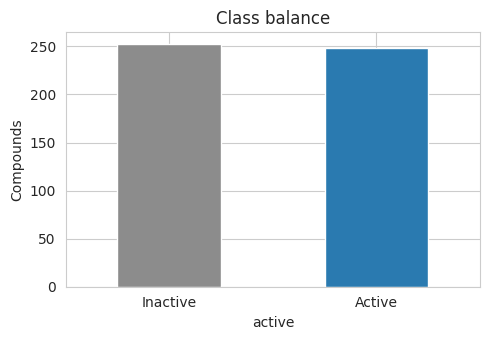

In [6]:
counts = df["active"].value_counts().sort_index()
print(counts)

ax = counts.rename({0: "Inactive", 1: "Active"}).plot(
    kind="bar", color=["#8c8c8c", "#2a7ab0"], rot=0, figsize=(5, 3.5))
ax.set_title("Class balance")
ax.set_ylabel("Compounds")
plt.tight_layout()
plt.show()

The classes are balanced (252 inactive, 248 active), so accuracy is a fair metric. I still report precision, recall and ROC-AUC next to it. There are no missing values or duplicates, which is expected for generated data.

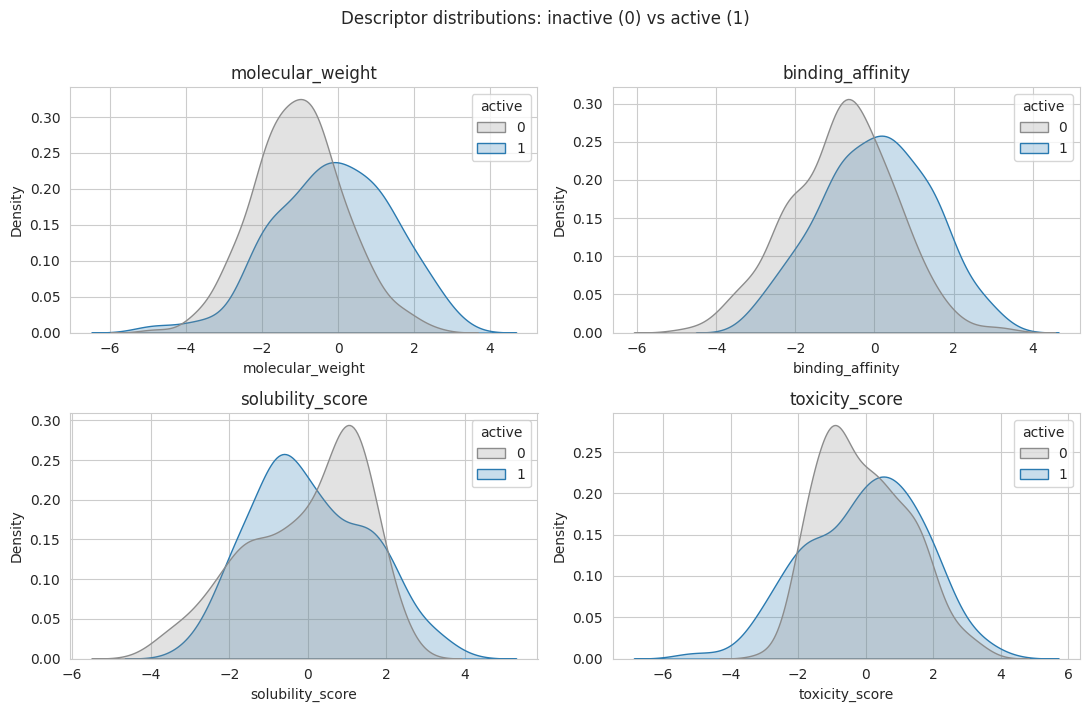

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.ravel(), features):
    sns.kdeplot(data=df, x=col, hue="active", fill=True, common_norm=False,
                palette={0: "#8c8c8c", 1: "#2a7ab0"}, ax=ax)
    ax.set_title(col)
plt.suptitle("Descriptor distributions: inactive (0) vs active (1)", y=1.01)
plt.tight_layout()
plt.show()

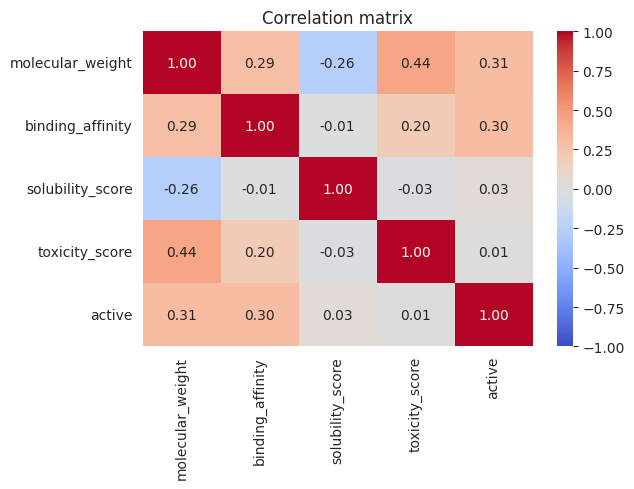

In [8]:
plt.figure(figsize=(6.5, 5))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

**What the plots show**
- `molecular_weight` (r = 0.31) and `binding_affinity` (r = 0.30) have a clear linear relationship with activity.
- `solubility_score` (r = 0.03) and `toxicity_score` (r = 0.01) show almost no linear correlation with activity. Their distributions still differ between the classes in shape, not just in position, so the signal is there but it is not a straight line.
- `molecular_weight` and `toxicity_score` are moderately correlated with each other (r = 0.44).

A correlation matrix only measures straight-line relationships. I keep all four features and let the models and the importance analysis show what each one contributes.

## 3. Train/test split

I split **before** scaling or tuning anything. Scaling the full dataset first would let the test set's mean and variance leak into training and make the test score slightly optimistic.

From here on the test set is left alone until the final evaluation. Scaling sits inside a `Pipeline`, so during cross-validation it is fitted only on the training folds.

In [9]:
X = df[features]
y = df["active"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Active share - train: {:.2f}, test: {:.2f}".format(y_train.mean(), y_test.mean()))

Train: (400, 4)  Test: (100, 4)
Active share - train: 0.49, test: 0.50


## 4. Comparing models with cross-validation

Five models, each in the same pipeline (scaler + model), compared with 5-fold stratified cross-validation on the training set only.

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

candidates = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=15),
    "SVM (RBF)": SVC(probability=True, random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=SEED),
    "Gradient Boosting": GradientBoostingClassifier(random_state=SEED),
}

scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]
rows = []
for name, model in candidates.items():
    pipe = Pipeline([("scaler", StandardScaler()), ("model", model)])
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring)
    row = {"model": name}
    for s in scoring:
        row[s] = res[f"test_{s}"].mean()
    row["roc_auc_std"] = res["test_roc_auc"].std()
    rows.append(row)

cv_results = pd.DataFrame(rows).sort_values("roc_auc", ascending=False).reset_index(drop=True)
cv_results.round(3)

,model,accuracy,precision,recall,f1,roc_auc,roc_auc_std
0,Random Forest,0.860,0.878,0.834,0.854,0.931,0.049
1,SVM (RBF),0.852,0.890,0.804,0.842,0.917,0.047
2,KNN,0.812,0.847,0.764,0.799,0.917,0.038
3,Gradient Boosting,0.828,0.840,0.804,0.818,0.914,0.054
4,Logistic Regression,0.675,0.672,0.677,0.671,0.736,0.077


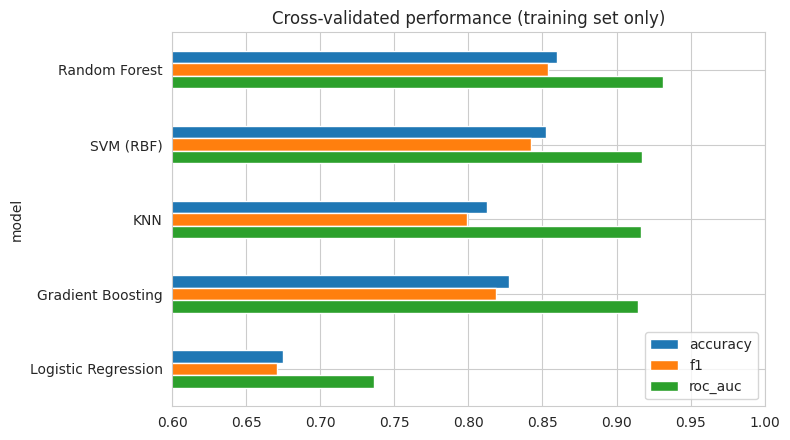

In [11]:
ax = cv_results.set_index("model")[["accuracy", "f1", "roc_auc"]].plot(kind="barh", figsize=(8, 4.5))
ax.set_xlim(0.6, 1.0)
ax.set_title("Cross-validated performance (training set only)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Random Forest leads with a cross-validated ROC-AUC of 0.931, followed by SVM and KNN (both 0.917) and Gradient Boosting (0.914). Logistic regression is far behind at 0.736.

That gap is the most informative result so far. Logistic regression can only draw a straight boundary, and it fails here because part of the signal is non-linear, which matches what the correlation matrix hinted at. I take the top two, Random Forest and SVM, forward to tuning.

## 5. Hyperparameter tuning

GridSearchCV runs on the training data with the same folds, so the test set still plays no part. The grids are small on purpose: 400 training rows do not justify a large search, and big grids tend to overfit the validation folds.

In [12]:
rf_pipe = Pipeline([("scaler", StandardScaler()),
                    ("model", RandomForestClassifier(random_state=SEED))])
rf_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 6, 10],
    "model__min_samples_leaf": [1, 3],
    "model__max_features": ["sqrt", None],
}

svm_pipe = Pipeline([("scaler", StandardScaler()),
                     ("model", SVC(probability=True, random_state=SEED))])
svm_grid = {
    "model__C": [0.3, 1, 3, 10],
    "model__gamma": ["scale", 0.1, 0.3, 1.0],
}

searches = {}
for name, pipe, grid in [("Random Forest", rf_pipe, rf_grid), ("SVM (RBF)", svm_pipe, svm_grid)]:
    gs = GridSearchCV(pipe, grid, cv=cv, scoring="roc_auc", n_jobs=-1)
    gs.fit(X_train, y_train)
    searches[name] = gs
    print(f"{name}: best CV ROC-AUC = {gs.best_score_:.4f}")
    print("   ", {k.replace("model__", ""): v for k, v in gs.best_params_.items()})

Random Forest: best CV ROC-AUC = 0.9320
    {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 400}


SVM (RBF): best CV ROC-AUC = 0.9250
    {'C': 3, 'gamma': 'scale'}


In [13]:
best_name = max(searches, key=lambda k: searches[k].best_score_)
best_model = searches[best_name].best_estimator_
print("Selected model:", best_name)

Selected model: Random Forest


Tuning moved the scores only slightly. Random Forest reached 0.932 with 400 trees and otherwise default settings, and SVM reached 0.925 with C = 3. Random Forest is selected.

I choose the final model on its cross-validated score. Choosing it on test-set performance would be another form of leakage.

## 6. Final evaluation on the test set

This is the first time the model sees the 100 held-out compounds.

In [14]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

test_metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_prob),
}
pd.Series(test_metrics).round(3)

accuracy     0.870
precision    0.894
recall       0.840
f1           0.866
roc_auc      0.949
dtype: float64

              precision    recall  f1-score   support

    Inactive      0.849     0.900     0.874        50
      Active      0.894     0.840     0.866        50

    accuracy                          0.870       100
   macro avg      0.871     0.870     0.870       100
weighted avg      0.871     0.870     0.870       100



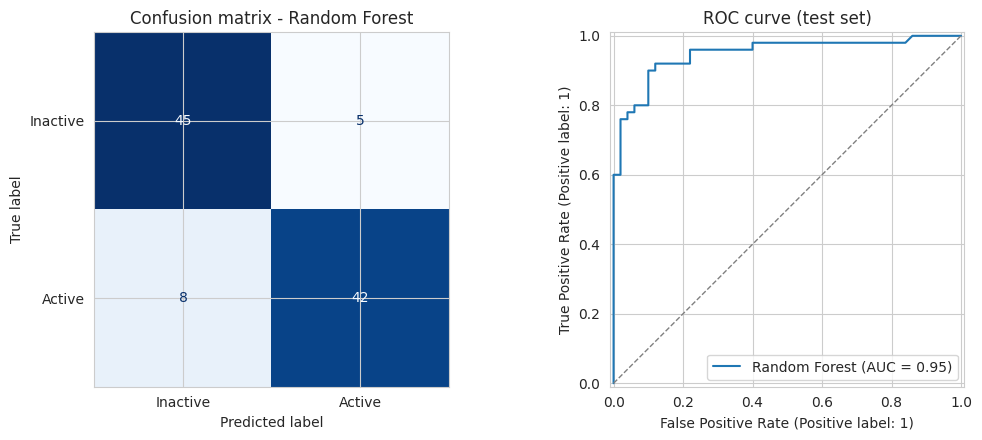

In [15]:
print(classification_report(y_test, y_pred, target_names=["Inactive", "Active"], digits=3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Inactive", "Active"],
                                        cmap="Blues", colorbar=False, ax=axes[0])
axes[0].set_title(f"Confusion matrix - {best_name}")
RocCurveDisplay.from_predictions(y_test, y_prob, name=best_name, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "--", color="grey", lw=1)
axes[1].set_title("ROC curve (test set)")
plt.tight_layout()
plt.show()

In [16]:
# overfitting check: training, cross-validation and test scores side by side
train_auc = roc_auc_score(y_train, best_model.predict_proba(X_train)[:, 1])
print(f"Train ROC-AUC: {train_auc:.3f}")
print(f"CV ROC-AUC:    {searches[best_name].best_score_:.3f}")
print(f"Test ROC-AUC:  {test_metrics['roc_auc']:.3f}")

Train ROC-AUC: 1.000
CV ROC-AUC:    0.932
Test ROC-AUC:  0.949


On the test set the model gets 87 of 100 compounds right, with precision 0.89, recall 0.84 and ROC-AUC 0.949.

The training score is 1.000. That is normal for a random forest, which can fit its own training data almost perfectly, so it says nothing about generalisation. The honest comparison is cross-validation against test: 0.932 against 0.949, which agree within the fold-to-fold spread. The model is not overfitting in a way that hurts new compounds.

The confusion matrix shows 8 active compounds missed. In a real screen a missed active is a lost lead, while a false positive only costs one extra assay, so in practice I would lower the decision threshold to catch more actives. The app lets the user do exactly that.

## 7. Which descriptors drive the predictions?

Permutation importance shuffles one feature at a time on the test set and measures how much ROC-AUC drops. It works for any model, and because the model is already fixed, using the test set here does not influence any modelling decision.

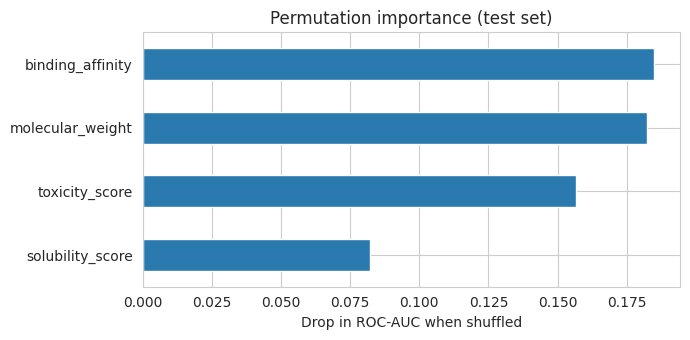

binding_affinity    0.185
molecular_weight    0.182
toxicity_score      0.157
solubility_score    0.082
dtype: float64

In [17]:
perm = permutation_importance(best_model, X_test, y_test, scoring="roc_auc",
                              n_repeats=20, random_state=SEED)
importance = pd.Series(perm.importances_mean, index=features).sort_values()

importance.plot(kind="barh", color="#2a7ab0", figsize=(7, 3.5))
plt.xlabel("Drop in ROC-AUC when shuffled")
plt.title("Permutation importance (test set)")
plt.tight_layout()
plt.show()

importance.sort_values(ascending=False).round(3)

All four descriptors matter. Binding affinity (0.185), molecular weight (0.182) and toxicity score (0.157) have the largest effect, and solubility score (0.082) still contributes clearly.

The interesting part is toxicity and solubility. Both had almost zero correlation with activity in the EDA, yet the model depends on them. Their relationship with activity is non-linear, so a correlation coefficient misses it and a random forest finds it. That is also why logistic regression scored so much lower.

## 8. Getting the model into the app

The Streamlit app (`app.py`) rebuilds this exact pipeline when it starts: the same generated data, the same split, and a Random Forest with 400 trees and seed 42. It trains in about a second.

I first deployed a saved model file instead. It broke on Streamlit Cloud because the server installed a newer scikit-learn than the one that saved the file, and pickled models are tied to the version that wrote them. Rebuilding from a fixed seed avoids that problem completely, and the check below confirms it gives the same model as the notebook.

In [18]:
# the same model the app builds: 400 trees, all other settings default
app_model = Pipeline([("scaler", StandardScaler()),
                      ("model", RandomForestClassifier(n_estimators=400, random_state=SEED))])
app_model.fit(X_train, y_train)

same = np.allclose(app_model.predict_proba(X_test), best_model.predict_proba(X_test))
print("App model identical to the tuned notebook model:", same)

# a few test compounds so the app's batch mode has something to try
X_test.head(10).round(4).to_csv("sample_compounds.csv", index=False)
print("Saved sample_compounds.csv")

App model identical to the tuned notebook model: True
Saved sample_compounds.csv


## Part A summary

- **Data:** 500 simulated compounds, 4 informative descriptors, balanced classes.
- **Leakage control:** split first, scaling inside the pipeline, tuning and model selection by cross-validation on the training set only, test set used once.
- **Model:** Random Forest, chosen on cross-validated ROC-AUC (0.932). On the held-out test set: accuracy 0.87, precision 0.89, recall 0.84, ROC-AUC 0.949.
- **Descriptors:** all four contribute. Two of them act non-linearly, which is why the tree-based model beats logistic regression by a wide margin.

---

# Part B: Real chemistry

Part A showed the modelling workflow on simulated data. This part works with actual molecules.

It builds on the fingerprint screening I did earlier in the bootcamp, where I encoded a small candidate library and ranked it by similarity to **imatinib**, the kinase inhibitor used for chronic myeloid leukaemia.

| | Question it answers |
|---|---|
| **Part A classifier** | Given this compound's properties, does it look like the actives I trained on? |
| **Part B similarity screen** | How structurally close is this compound to one specific known drug? |

In [19]:
from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import Descriptors, Crippen, Lipinski, Draw, rdFingerprintGenerator

RDLogger.DisableLog("rdApp.*")   # silence minor valence warnings
print("RDKit ready")

RDKit ready


## B1. A real candidate library

Seventeen approved drugs written as **SMILES**. A SMILES string spells a molecule out as text: `CCO` is ethanol, two carbons then an oxygen. Lowercase letters mean aromatic atoms, so benzene is `c1ccccc1`.

The library has imatinib as the reference, eight other kinase inhibitors, and eight unrelated drugs as negative controls.

In [20]:
library = {
    # the reference compound
    "Imatinib":    "Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1Nc1nccc(-c2cccnc2)n1",
    # other kinase inhibitors
    "Dasatinib":   "Cc1nc(Nc2ncc(C(=O)Nc3c(C)cccc3Cl)s2)cc(N2CCN(CCO)CC2)n1",
    "Gefitinib":   "COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCOCC1",
    "Erlotinib":   "C#Cc1cccc(Nc2ncnc3cc(OCCOC)c(OCCOC)cc23)c1",
    "Afatinib":    "CN(C)C/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1O[C@H]1CCOC1",
    "Osimertinib": "C=CC(=O)Nc1cc(Nc2nccc(-c3cn(C)c4ccccc34)n2)c(OC)cc1N(C)CCN(C)C",
    "Lapatinib":   "CS(=O)(=O)CCNCc1ccc(-c2ccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c3c2)o1",
    "Sorafenib":   "CNC(=O)c1cc(Oc2ccc(NC(=O)Nc3ccc(Cl)c(C(F)(F)F)c3)cc2)ccn1",
    "Sunitinib":   "CCN(CC)CCNC(=O)c1c(C)[nH]c(/C=C2\\C(=O)Nc3ccc(F)cc32)c1C",
    # unrelated drugs, used as negative controls
    "Aspirin":     "CC(=O)Oc1ccccc1C(=O)O",
    "Caffeine":    "Cn1c(=O)c2c(ncn2C)n(C)c1=O",
    "Paracetamol": "CC(=O)Nc1ccc(O)cc1",
    "Ibuprofen":   "CC(C)Cc1ccc(C(C)C(=O)O)cc1",
    "Metformin":   "CN(C)C(=N)NC(N)=N",
    "Diclofenac":  "O=C(O)Cc1ccccc1Nc1c(Cl)cccc1Cl",
    "Warfarin":    "CC(=O)CC(c1ccccc1)c1c(O)c2ccccc2oc1=O",
    "Nicotine":    "CN1CCC[C@H]1c1cccnc1",
}
kinase_inhibitors = {"Imatinib", "Dasatinib", "Gefitinib", "Erlotinib", "Afatinib",
                     "Osimertinib", "Lapatinib", "Sorafenib", "Sunitinib"}

mols = {name: Chem.MolFromSmiles(smi) for name, smi in library.items()}
failed = [n for n, m in mols.items() if m is None]
print(f"Parsed {len(mols) - len(failed)} of {len(mols)} molecules", "| failed:", failed or "none")

Parsed 17 of 17 molecules | failed: none


In [21]:
# a mistyped SMILES often still parses into the wrong molecule, so check each
# structure against its published molecular formula before using it
from rdkit.Chem.rdMolDescriptors import CalcMolFormula

published = {
    "Imatinib": "C29H31N7O", "Dasatinib": "C22H26ClN7O2S", "Gefitinib": "C22H24ClFN4O3",
    "Erlotinib": "C22H23N3O4", "Afatinib": "C24H25ClFN5O3", "Osimertinib": "C28H33N7O2",
    "Lapatinib": "C29H26ClFN4O4S", "Sorafenib": "C21H16ClF3N4O3", "Sunitinib": "C22H27FN4O2",
    "Aspirin": "C9H8O4", "Caffeine": "C8H10N4O2", "Paracetamol": "C8H9NO2",
    "Ibuprofen": "C13H18O2", "Metformin": "C4H11N5", "Diclofenac": "C14H11Cl2NO2",
    "Warfarin": "C19H16O4", "Nicotine": "C10H14N2",
}
mismatch = {n: CalcMolFormula(m) for n, m in mols.items() if CalcMolFormula(m) != published[n]}
print("All formulas match the published values" if not mismatch else f"Mismatch: {mismatch}")

All formulas match the published values


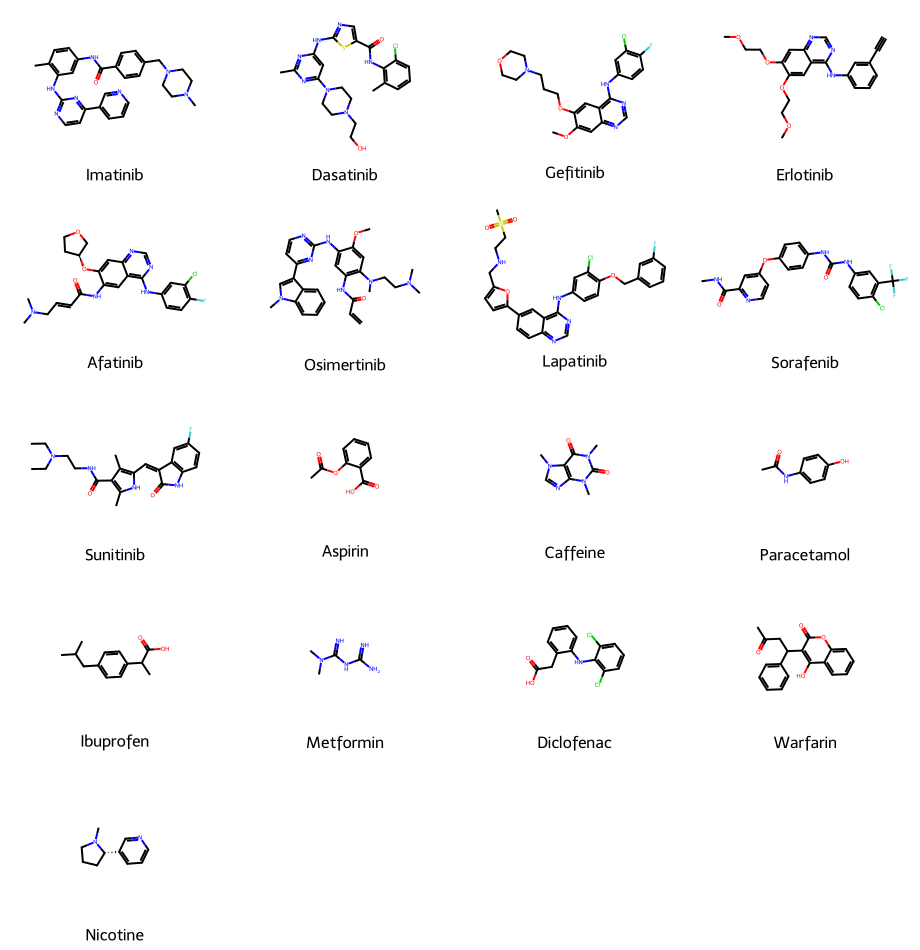

In [22]:
names = list(mols)
Draw.MolsToGridImage([mols[n] for n in names], molsPerRow=4,
                     subImgSize=(230, 190), legends=names)

## B2. Real molecular descriptors

These are calculated from the actual structures.

| Descriptor | What it means |
|---|---|
| **MolWt** | Molecular weight. Large molecules are often poorly absorbed. |
| **LogP** | Lipophilicity, how much it prefers fat over water. |
| **TPSA** | Topological polar surface area. High values struggle to cross membranes. |
| **HBD / HBA** | Hydrogen bond donors and acceptors. |
| **RotB** | Rotatable bonds, a measure of flexibility. |
| **AromRings** | Aromatic rings, common in kinase inhibitors. |

**Lipinski's rule of five** is the classic oral-drug guideline: weight ≤ 500, LogP ≤ 5, donors ≤ 5, acceptors ≤ 10.

In [23]:
def compute_descriptors(mol):
    return {
        "MolWt":     Descriptors.MolWt(mol),
        "LogP":      Crippen.MolLogP(mol),
        "TPSA":      Descriptors.TPSA(mol),
        "HBD":       Lipinski.NumHDonors(mol),
        "HBA":       Lipinski.NumHAcceptors(mol),
        "RotB":      Lipinski.NumRotatableBonds(mol),
        "AromRings": Lipinski.NumAromaticRings(mol),
    }

desc = pd.DataFrame([compute_descriptors(m) for m in mols.values()], index=list(mols))
desc["Lipinski_violations"] = (
    (desc.MolWt > 500).astype(int) + (desc.LogP > 5).astype(int)
    + (desc.HBD > 5).astype(int) + (desc.HBA > 10).astype(int)
)
desc["class"] = ["kinase inhibitor" if n in kinase_inhibitors else "other drug" for n in desc.index]

desc.round(2)

,MolWt,LogP,TPSA,HBD,HBA,RotB,AromRings,Lipinski_violations,class
Imatinib,493.62,4.59,86.28,2,7,7,4,0,kinase inhibitor
Dasatinib,488.02,3.31,106.51,3,9,7,3,0,kinase inhibitor
Gefitinib,446.91,4.28,68.74,1,7,8,3,0,kinase inhibitor
Erlotinib,393.44,3.41,74.73,1,7,10,3,0,kinase inhibitor
Afatinib,485.95,4.39,88.61,2,7,8,3,0,kinase inhibitor
Osimertinib,499.62,4.51,87.55,2,7,10,4,0,kinase inhibitor
Lapatinib,581.07,6.14,106.35,2,8,11,5,2,kinase inhibitor
Sorafenib,464.83,5.55,92.35,3,4,5,3,1,kinase inhibitor
Sunitinib,398.48,3.33,77.23,3,3,7,2,0,kinase inhibitor
Aspirin,180.16,1.31,63.60,1,3,2,1,0,other drug


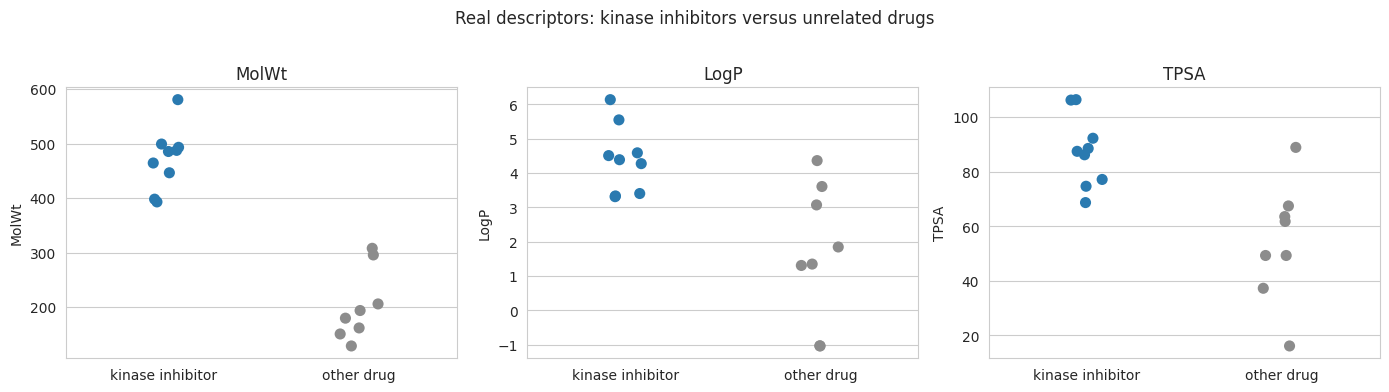

Average by group:
                  MolWt  LogP  TPSA  AromRings
class                                         
kinase inhibitor  472.4   4.4  87.6        3.3
other drug        203.5   1.7  54.3        1.4

Over 500 Da: ['Lapatinib']
LogP over 5: ['Lapatinib', 'Sorafenib']


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for ax, col in zip(axes, ["MolWt", "LogP", "TPSA"]):
    sns.stripplot(data=desc, x="class", y=col, hue="class", s=8, ax=ax,
                  palette={"kinase inhibitor": "#2a7ab0", "other drug": "#8c8c8c"}, legend=False)
    ax.set_title(col)
    ax.set_xlabel("")
plt.suptitle("Real descriptors: kinase inhibitors versus unrelated drugs", y=1.02)
plt.tight_layout()
plt.show()

print("Average by group:")
print(desc.groupby("class")[["MolWt", "LogP", "TPSA", "AromRings"]].mean().round(1))
print("\nOver 500 Da:", list(desc.index[desc.MolWt > 500]))
print("LogP over 5:", list(desc.index[desc.LogP > 5]))

The kinase inhibitors are clearly larger and more aromatic: on average 472 Da against 203 Da, and 3.3 aromatic rings against 1.4. They have to fill a sizeable pocket in the kinase active site, which pushes size up.

Only lapatinib breaks the 500 Da limit, and lapatinib and sorafenib both have LogP above 5. Both are approved oral drugs anyway, which is a good reminder that the rule of five is a guideline and not a law.

## B3. Morgan fingerprints and similarity to imatinib

Descriptors say what a molecule is *like*. Fingerprints say what it is *made of*.

A **Morgan fingerprint** looks at the neighbourhood around every atom, out to a fixed radius, and sets one bit in a long binary vector for each neighbourhood it finds. Radius 2 means each bit covers an atom plus everything within two bonds.

**Tanimoto similarity** compares two fingerprints: bits set in both, divided by bits set in either. It runs from 0 (nothing shared) to 1 (identical fingerprints).

In [25]:
# radius 2, 2048 bits: the usual starting point for this kind of screen
morgan = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
fingerprints = {name: morgan.GetFingerprint(mol) for name, mol in mols.items()}

example = morgan.GetFingerprintAsNumPy(mols["Imatinib"])
print(f"Fingerprint length: {len(example)} bits")
print(f"Bits set for imatinib: {int(example.sum())} ({example.mean():.1%} of the vector)")

Fingerprint length: 2048 bits
Bits set for imatinib: 65 (3.2% of the vector)


In [26]:
REFERENCE = "Imatinib"

others = [n for n in fingerprints if n != REFERENCE]
scores = DataStructs.BulkTanimotoSimilarity(
    fingerprints[REFERENCE], [fingerprints[n] for n in others]
)

ranking = (pd.DataFrame({
        "compound": others,
        "tanimoto_to_imatinib": scores,
        "class": ["kinase inhibitor" if n in kinase_inhibitors else "other drug" for n in others],
    })
    .sort_values("tanimoto_to_imatinib", ascending=False)
    .reset_index(drop=True))
ranking.index += 1
ranking.round(3)

,compound,tanimoto_to_imatinib,class
1,Dasatinib,0.275,kinase inhibitor
2,Osimertinib,0.262,kinase inhibitor
3,Nicotine,0.218,other drug
4,Sorafenib,0.196,kinase inhibitor
5,Gefitinib,0.168,kinase inhibitor
6,Afatinib,0.158,kinase inhibitor
7,Paracetamol,0.149,other drug
8,Diclofenac,0.143,other drug
9,Lapatinib,0.140,kinase inhibitor
10,Erlotinib,0.131,kinase inhibitor


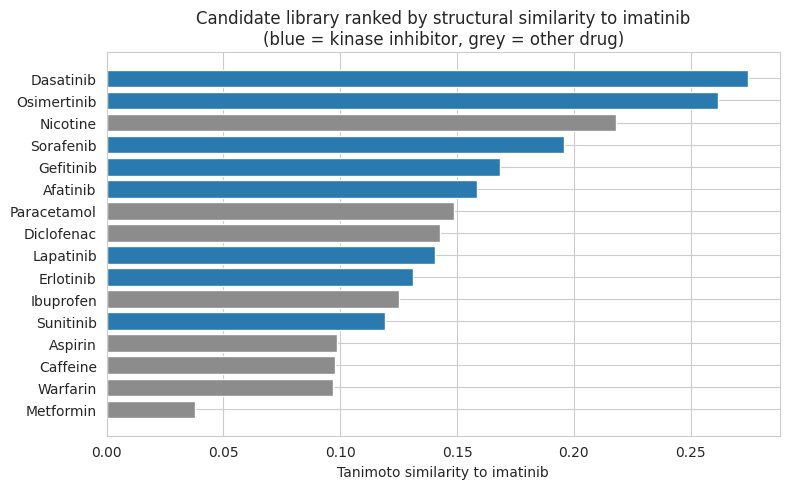

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))
colours = ["#2a7ab0" if c == "kinase inhibitor" else "#8c8c8c" for c in ranking["class"]]
ax.barh(ranking.compound[::-1], ranking.tanimoto_to_imatinib[::-1], color=colours[::-1])
ax.set_xlabel("Tanimoto similarity to imatinib")
ax.set_title("Candidate library ranked by structural similarity to imatinib\n(blue = kinase inhibitor, grey = other drug)")
plt.tight_layout()
plt.show()

In [28]:
# did the ranking actually separate the two groups?
top5 = ranking.head(5)
hit_rate = (top5["class"] == "kinase inhibitor").mean()
base_rate = (ranking["class"] == "kinase inhibitor").mean()
print(f"Kinase inhibitors in the top 5:   {hit_rate:.0%}")
print(f"Kinase inhibitors in the library: {base_rate:.0%}")
print(f"Enrichment: {hit_rate / base_rate:.2f}x over picking at random")

Kinase inhibitors in the top 5:   80%
Kinase inhibitors in the library: 50%
Enrichment: 1.60x over picking at random


**Reading these numbers honestly.** Dasatinib is the closest match at 0.275, and four of the top five are kinase inhibitors against a 50% base rate, a 1.6x enrichment.

The absolute similarities are low. A common rule of thumb treats values above about 0.7 as the same chemical series, and nothing here comes close. That is the correct result: these are separately discovered drugs from different chemical series, not variants of one scaffold. What matters for screening is the *ordering*.

The ranking is not perfect either. Nicotine sits third, above several kinase inhibitors. It is a small molecule with few fingerprint bits, and Tanimoto divides by the bits set in either molecule, so a small molecule can score higher than it deserves. A real screen would combine similarity with a simple property filter, and nicotine would drop out immediately on size.

It is also worth being clear about what a similarity screen cannot do. It only finds molecules that look like the reference, so it will never discover an active with a new scaffold. That is why the field also trains classifiers like the one in Part A.

Most similar to imatinib: Dasatinib (Tanimoto 0.275)


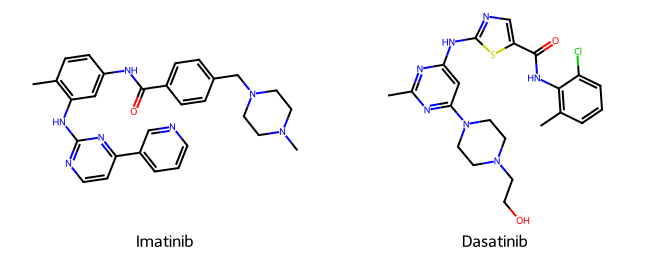

In [29]:
best_match = ranking.compound.iloc[0]
print(f"Most similar to imatinib: {best_match} (Tanimoto {ranking.tanimoto_to_imatinib.iloc[0]:.3f})")
Draw.MolsToGridImage([mols[REFERENCE], mols[best_match]], molsPerRow=2,
                     subImgSize=(330, 260), legends=[REFERENCE, best_match])

**What a real analogue looks like.** Nilotinib is not in the library. It is a later leukaemia drug that was developed starting from imatinib's structure, so it is a genuine analogue. Scoring it shows the difference between a relative and a drug from a separate series.

In [30]:
nilotinib = Chem.MolFromSmiles("Cc1cn(-c2cc(NC(=O)c3ccc(C)c(Nc4nccc(-c5cccnc5)n4)c3)cc(C(F)(F)F)c2)cn1")
print("Formula:", CalcMolFormula(nilotinib), "(published C28H22F3N7O)")

nil_score = DataStructs.TanimotoSimilarity(morgan.GetFingerprint(nilotinib), fingerprints[REFERENCE])
print(f"Nilotinib vs imatinib: {nil_score:.3f}")
print(f"Best score inside the library: {ranking.tanimoto_to_imatinib.max():.3f} ({ranking.compound.iloc[0]})")

Formula: C28H22F3N7O (published C28H22F3N7O)
Nilotinib vs imatinib: 0.517
Best score inside the library: 0.275 (Dasatinib)


Nilotinib scores 0.517, almost twice dasatinib. The library drugs score low because they are separate chemical series, and a true relative stands out clearly. This is the kind of compound a similarity screen is designed to find.

In [31]:
# save the results so the Streamlit app can show them
library_table = desc.join(ranking.set_index("compound").tanimoto_to_imatinib)
library_table["tanimoto_to_imatinib"] = library_table["tanimoto_to_imatinib"].fillna(1.0)  # imatinib vs itself
library_table["smiles"] = pd.Series(library)
library_table.round(6).to_csv("candidate_library.csv")
print("Saved candidate_library.csv")
library_table.sort_values("tanimoto_to_imatinib", ascending=False).round(2)

Saved candidate_library.csv


,MolWt,LogP,TPSA,HBD,HBA,RotB,AromRings,Lipinski_violations,class,tanimoto_to_imatinib,smiles
Imatinib,493.62,4.59,86.28,2,7,7,4,0,kinase inhibitor,1.00,Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1Nc1nccc...
Dasatinib,488.02,3.31,106.51,3,9,7,3,0,kinase inhibitor,0.27,Cc1nc(Nc2ncc(C(=O)Nc3c(C)cccc3Cl)s2)cc(N2CCN(C...
Osimertinib,499.62,4.51,87.55,2,7,10,4,0,kinase inhibitor,0.26,C=CC(=O)Nc1cc(Nc2nccc(-c3cn(C)c4ccccc34)n2)c(O...
Nicotine,162.24,1.85,16.13,0,2,1,1,0,other drug,0.22,CN1CCC[C@H]1c1cccnc1
Sorafenib,464.83,5.55,92.35,3,4,5,3,1,kinase inhibitor,0.20,CNC(=O)c1cc(Oc2ccc(NC(=O)Nc3ccc(Cl)c(C(F)(F)F)...
Gefitinib,446.91,4.28,68.74,1,7,8,3,0,kinase inhibitor,0.17,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCOCC1
Afatinib,485.95,4.39,88.61,2,7,8,3,0,kinase inhibitor,0.16,CN(C)C/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2...
Paracetamol,151.16,1.35,49.33,2,2,1,1,0,other drug,0.15,CC(=O)Nc1ccc(O)cc1
Diclofenac,296.15,4.36,49.33,2,2,4,2,0,other drug,0.14,O=C(O)Cc1ccccc1Nc1c(Cl)cccc1Cl
Lapatinib,581.07,6.14,106.35,2,8,11,5,2,kinase inhibitor,0.14,CS(=O)(=O)CCNCc1ccc(-c2ccc3ncnc(Nc4ccc(OCc5ccc...


## Part B summary

- The molecules are real, every structure was checked against its published formula, and the descriptors come from the actual structures.
- The similarity screen puts kinase inhibitors near the top (1.6x enrichment in the top five), with nicotine as an instructive false positive.
- A genuine imatinib analogue, nilotinib, scores 0.517, far above anything in the library.

**One thing I deliberately did not do.** The Part A classifier is not applied to these real molecules. It was trained on simulated features whose scales have nothing to do with real descriptors, so its output here would look valid and mean nothing. Training a classifier on real molecules needs measured activity data, such as IC50 values from ChEMBL. That is the next step for this project.